In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
#unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zona_logistica\esp840_1620_02_2026.csv',sep=',') #for csv files.
unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\arauca\Export (1).xlsx') #For xls files.
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1441 non-null   str  
 1   Message  1441 non-null   str  
 2   Status   1441 non-null   str  
dtypes: str(3)
memory usage: 33.9 KB


Odometer

      Odometer in  Odometer en miles
0       124203973       77176.746907
1       124203973       77176.746907
2       124203973       77176.746907
3       124203973       77176.746907
4       124203973       77176.746907
...           ...                ...
1436    124348300       77266.427519
1437    124348669       77266.656805
1438    124348684       77266.666126
1439    124348692       77266.671097
1440    124348692       77266.671097

[1441 rows x 2 columns]


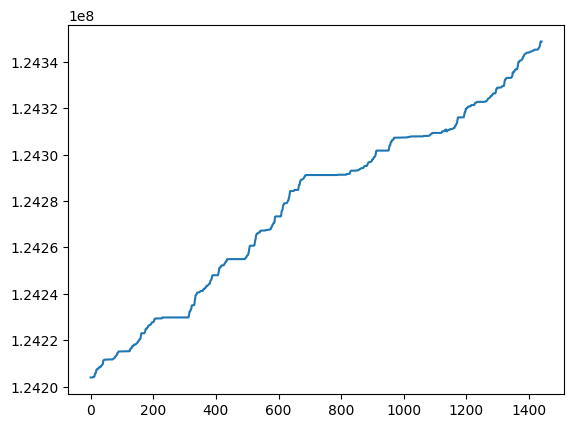

In [12]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

print(unit_odometer)
unit_odometer
plt.plot(x_axis,aux)

Harsh turn

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [13]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

Satellite number

In [14]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<2:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<2:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-04-14 10:31:47.546  ->  0
2026-04-14 10:31:47.687  ->  0
2026-04-14 10:31:47.827  ->  0
2026-04-14 10:31:47.965  ->  0
2026-04-14 10:31:48.105  ->  0
2026-04-14 10:31:48.259  ->  0
2026-04-14 10:31:48.815  ->  0
2026-04-14 10:31:48.955  ->  0
2026-04-14 10:31:49.515  ->  0
2026-04-14 10:34:07.779  ->  1
2026-04-14 10:53:21.708  ->  0
2026-04-14 10:53:21.841  ->  0
2026-04-14 10:53:21.981  ->  0
2026-04-14 12:42:44.183  ->  0
2026-04-14 12:42:44.299  ->  0
2026-04-14 12:42:44.419  ->  0
2026-04-14 12:42:44.675  ->  0
2026-04-14 12:42:44.787  ->  0
2026-04-14 12:42:44.909  ->  0
2026-04-14 16:21:09.275  ->  0
2026-04-14 16:21:09.434  ->  0
2026-04-14 16:21:09.594  ->  0
2026-04-14 16:21:09.722  ->  0
2026-04-14 16:21:09.850  ->  0
2026-04-14 16:21:09.978  ->  0
2026-04-14 16:21:10.138  ->  0
2026-04-14 16:21:10.266  ->  0
2026-04-14 16:21:10.426  ->  0
2026-04-14 16:21:10.554  ->  0
2026-04-14 16:21:10.698  ->  0
2026-04-14 16:21:10.826  ->  0
2026-04-14 16:21:10.970  ->  0
2026-04-

Temperature

In [6]:
accum3=float(input('Type Accum 3 value: '))
celsius_temp=accum3*0.0625
farenheit_temp=(celsius_temp*9)/5+32
print('Celsius: ',celsius_temp,'farenheit: ',farenheit_temp)

Celsius:  21.875 farenheit:  71.375


In [ ]:
aux_temp=[]
for i in range(0,unit.shape[0]):    
    aux_temp.append(float(int(unit.iloc[i,2][96:100],16)*0.0625))
aux_temp

[999.0, 999.0, 999.0, 999.0, 28.8125, 28.625, 28.5625, 28.4375, 27.1875, 999.0]

Binary inputs

In [7]:
for i in range(0,unit.shape[0]):   
    if unit.iloc[i,2][64:66]=='0C': # Put the Even Code to look for.
        cont=cont+1
        print(bin(int(unit.iloc[i,2][62:64],16)),' -> ',unit.iloc[i,0])
print("Total event codes 0C input2 Off: ",cont)

Total event codes 0C input2 Off:  181


In [8]:
sequence=[]
sequence.append(unit.iloc[0,2][24:28])
sequence

['0022']

[0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 15, 21, 14, 12, 9, 20, 22, 0, 0, 19, 9, 16, 13, 17, 3, 8, 1, 0, 0, 0, 32, 14, 11, 11, 9, 0, 30, 10, 28, 0, 23, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 24, 9, 17, 23, 9, 16, 16, 10, 27, 15, 0, 28, 15, 16, 0, 5, 10, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 24, 24, 18, 15, 8, 11, 14, 8, 18, 18, 9, 8, 12, 12, 24, 0, 0, 0, 0, 27, 9, 15, 9, 15, 5, 19, 14, 7, 15, 10, 10, 13, 8, 8, 13, 28, 39, 7, 4, 0, 0, 0, 0, 0, 0, 0, 0, 25, 11, 25, 12, 12, 10, 9, 14, 9, 13, 12, 11, 13, 11, 9, 8, 9, 0, 19, 9, 0, 18, 14, 12, 11, 10, 0, 0, 12, 10, 22, 12, 9, 9, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

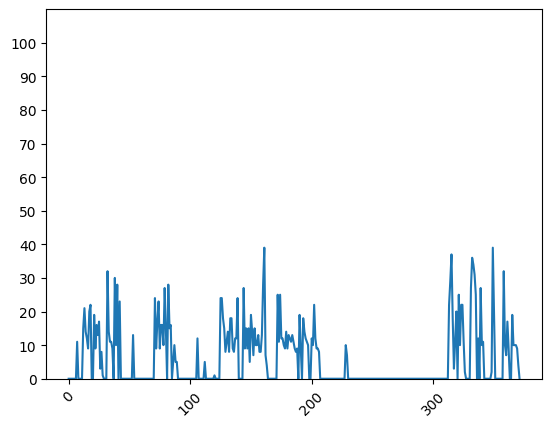

In [9]:
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)